## Executive Summary

This project aims to predict customer churn for a bank and identify the key factors driving customer attrition. Customer churn is a critical issue, as losing customers directly impacts revenue and growth.

Using machine learning models such as Logistic Regression, Random Forest, and XGBoost, we achieved a maximum accuracy of approximately 83%, with XGBoost performing the best overall.

Key findings indicate that customer activity status, tenure, and balance are the strongest predictors of churn. In particular, inactive customers and those with shorter tenure are significantly more likely to leave.

These insights can help the bank design targeted retention strategies, such as improving customer engagement and focusing on high-risk segments.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score

In [ ]:
url= '/content/Customer-Churn-Records.csv'
data=pd.read_csv(url)
data

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0,0,1,DIAMOND,300
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0,0,5,PLATINUM,771
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1,1,3,SILVER,564
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1,1,2,GOLD,339


The above dataset shows details of 10 000 individuals from a certain bank, showing from Gender, Age to the different Card Type they use.

In [ ]:
data.isna().sum().sum()

np.int64(0)

In [ ]:
data.duplicated().sum()

np.int64(0)

## Problem Statement

Customer churn refers to customers leaving a service provider. For banks, high churn rates can lead to significant financial losses.

The objective of this project is to:
- Predict whether a customer will churn
- Identify the most important factors influencing churn
- Provide actionable insights to reduce customer loss

In [ ]:
df=data.drop(['CustomerId','Surname', 'Geography','Gender', 'Card Type'], axis=1)
df

,RowNumber,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
0,1,619,42,2,0.00,1,1,1,101348.88,1,1,2,464
1,2,608,41,1,83807.86,1,0,1,112542.58,0,1,3,456
2,3,502,42,8,159660.80,3,1,0,113931.57,1,1,3,377
3,4,699,39,1,0.00,2,0,0,93826.63,0,0,5,350
4,5,850,43,2,125510.82,1,1,1,79084.10,0,0,5,425
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,771,39,5,0.00,2,1,0,96270.64,0,0,1,300
9996,9997,516,35,10,57369.61,1,1,1,101699.77,0,0,5,771
9997,9998,709,36,7,0.00,1,0,1,42085.58,1,1,3,564
9998,9999,772,42,3,75075.31,2,1,0,92888.52,1,1,2,339


In [ ]:
data.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Point Earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


In [ ]:
churn_rate = df['Exited'].mean()
print(f"Overall churn rate: {churn_rate:.2%}")

Overall churn rate: 20.38%


The overall churn rate is approximately 20.38%, indicating that a significant portion of customers are leaving the bank.

Text(0.5, 1.0, 'Age Distribution by Churn')

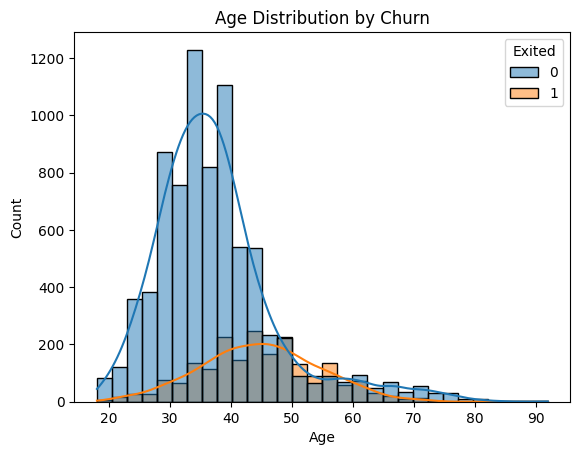

In [ ]:
sns.histplot(data=df, x='Age', hue='Exited', bins=30, kde=True)
plt.title("Age Distribution by Churn")

Younger customers show a higher tendency to churn compared to older customers.

<Axes: xlabel='Exited', ylabel='Balance'>

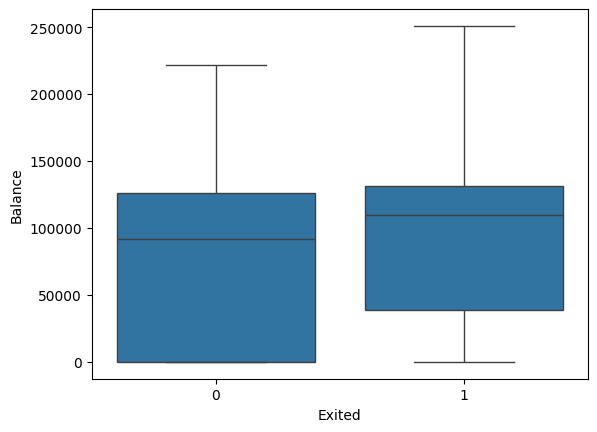

In [ ]:
sns.boxplot(x='Exited', y='Balance', data=df)

Customers with higher balances appear more likely to churn, suggesting dissatisfaction among high-value clients.

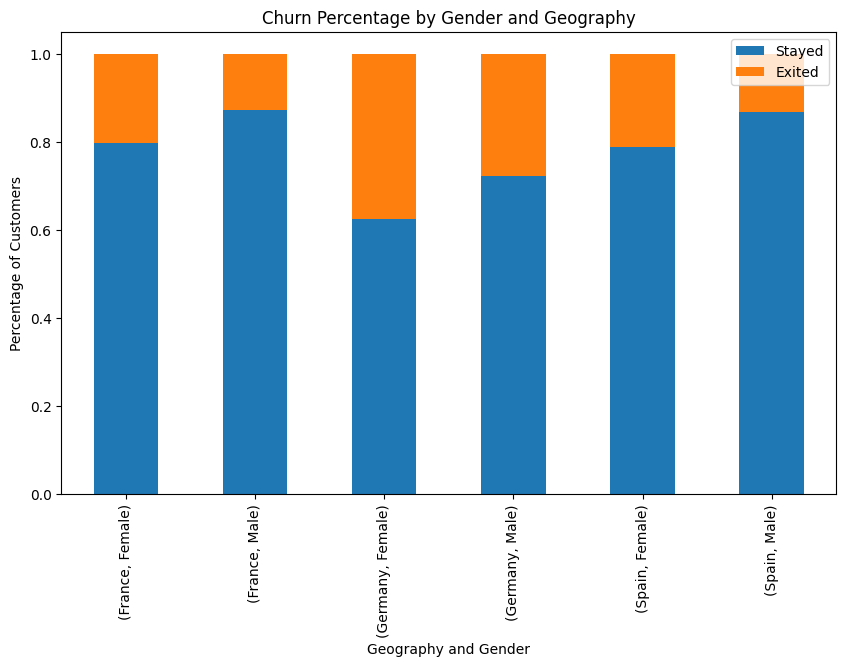

In [ ]:
churn_geo_gender = pd.crosstab([data['Geography'], data['Gender']], data['Exited'], normalize='index')
churn_geo_gender.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Churn Percentage by Gender and Geography')
plt.xlabel('Geography and Gender')
plt.ylabel('Percentage of Customers')
plt.legend(['Stayed', 'Exited'])
plt.show()

The Churn Percentage by Gender and Geography graph shows the churn rate for different combinations of geography and gender. As shown in the graph, the France citizens have a lower churn rate and females have a higher churn rate




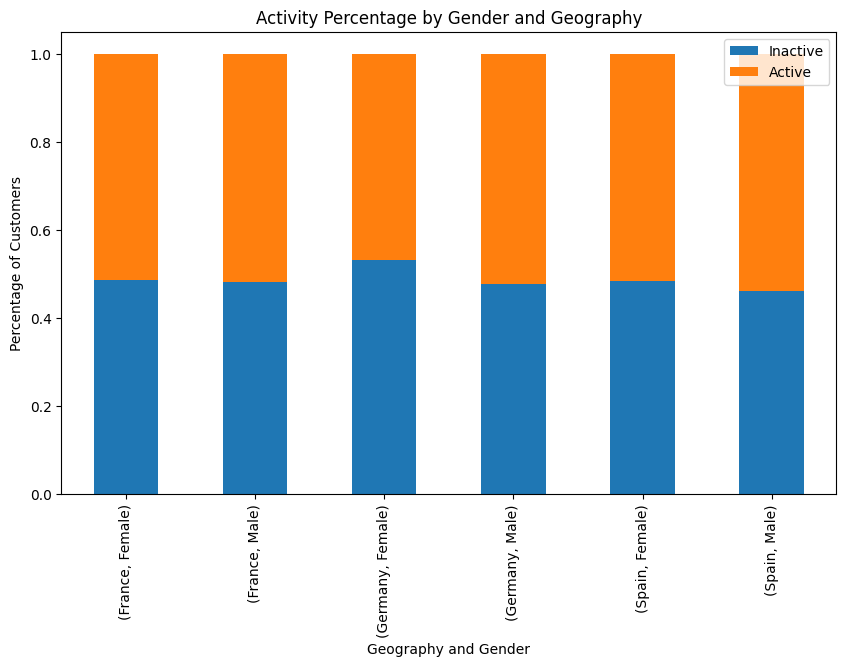

In [ ]:
activity_geo_gender = pd.crosstab([data['Geography'], data['Gender']], data['IsActiveMember'], normalize='index')
activity_geo_gender.plot(kind='bar', stacked=True, figsize=(10,6))
plt.title('Activity Percentage by Gender and Geography')
plt.xlabel('Geography and Gender')
plt.ylabel('Percentage of Customers')
plt.legend(['Inactive', 'Active'])
plt.show()

The Activity Percentage by Gender and Geography shows that females have more active members and Spain has a higher rate of inactive members


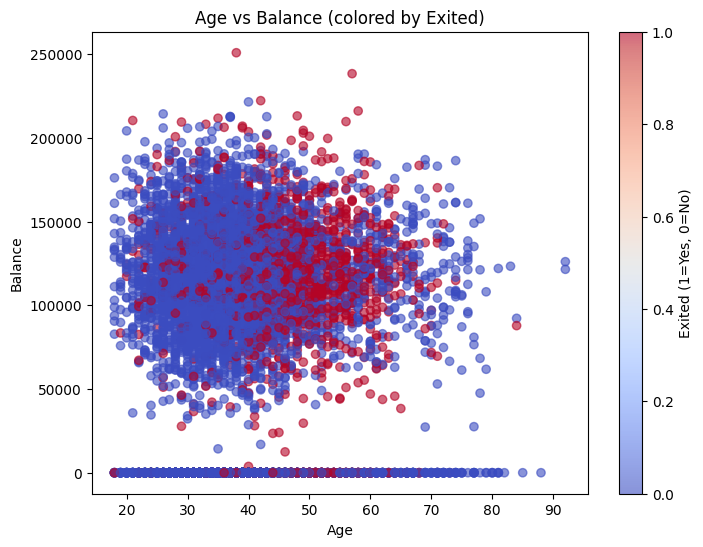

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data['Age'], data['Balance'], c=data['Exited'], cmap='coolwarm', alpha=0.6)
plt.title('Age vs Balance (colored by Exited)')
plt.xlabel('Age')
plt.ylabel('Balance')
plt.colorbar(label='Exited (1=Yes, 0=No)')
plt.show()

The 'Age vs Balance (colored by Exited)' graph shows that customers who churned (indicated by warm colors) are distributed across various age and balance ranges, without a clear, single cluster. This suggests that churn is not solely driven by a simple combination of age and balance, but could be influenced by other factors or more complex interactions among these variables.

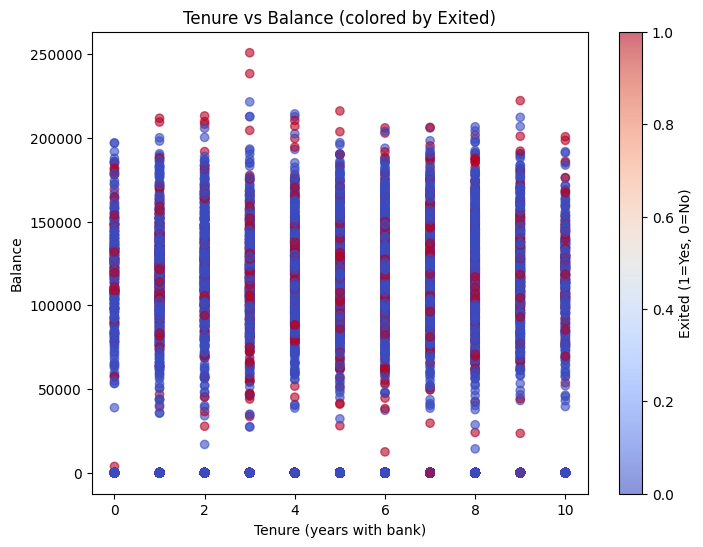

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(data['Tenure'], data['Balance'], c=data['Exited'], cmap='coolwarm', alpha=0.6)
plt.title('Tenure vs Balance (colored by Exited)')
plt.xlabel('Tenure (years with bank)')
plt.ylabel('Balance')
plt.colorbar(label='Exited (1=Yes, 0=No)')
plt.show()

The 'Tenure vs Balance (colored by Exited)' graph suggests that churned customers (warm colors) are distributed across different tenure and balance ranges. While there isn't a single clear cluster, the graph indicates that customers with lower tenure, even those with high balances, are still at risk of churning. This highlights the importance of early engagement and satisfaction to retain newly acquired customers, regardless of their financial standing.

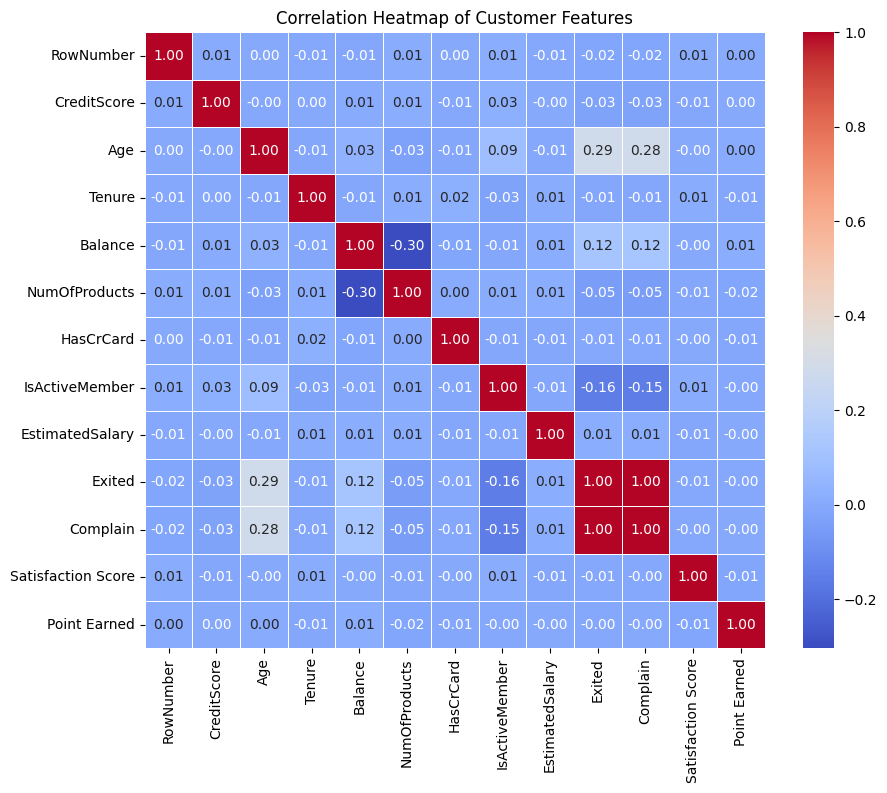

In [ ]:
plt.figure(figsize=(10,8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Customer Features')
plt.show()

## Data Cleaning and Feature Selection

The variable 'Complain' was removed to prevent data leakage. This is because complaints may be recorded after a customer has already decided to leave, which would introduce future information into the model.

Using such variables would artificially inflate model performance and reduce real-world reliability.

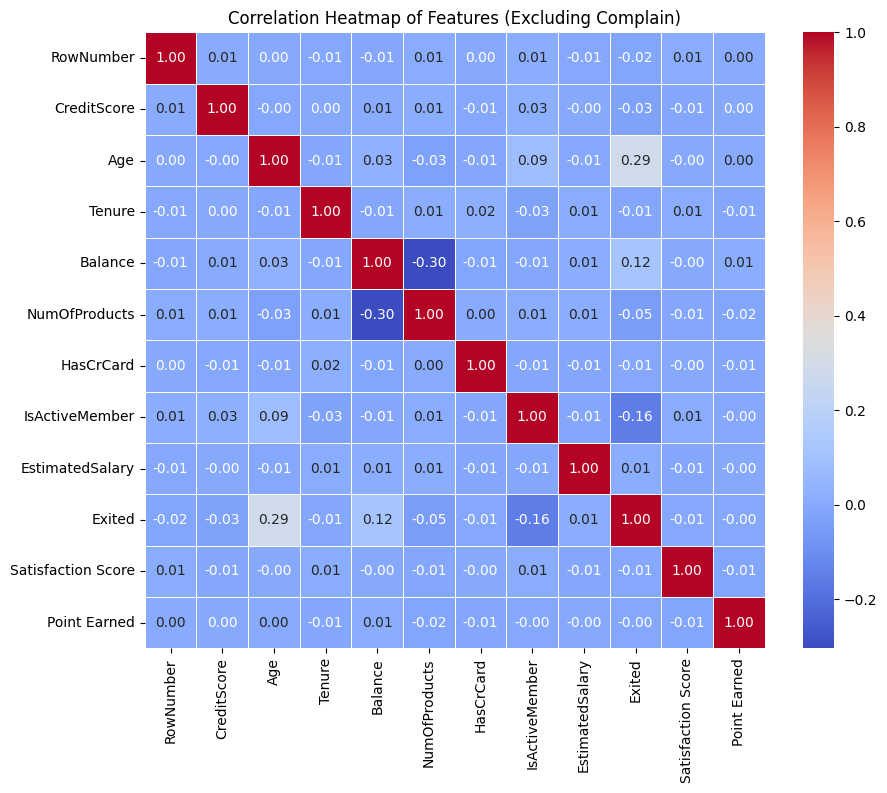

In [ ]:
plt.figure(figsize=(10,8))
df_no_complain = df.drop('Complain', axis=1)
corr_no_complain = df_no_complain.corr()
sns.heatmap(corr_no_complain, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap of Features (Excluding Complain)')
plt.show()

In [ ]:
X = df.drop(['Exited', 'Complain'], axis=1)
y = df['Exited']
X = pd.get_dummies(X, drop_first=True)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))


[[1557   50]
 [ 335   58]]
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1607
           1       0.54      0.15      0.23       393

    accuracy                           0.81      2000
   macro avg       0.68      0.56      0.56      2000
weighted avg       0.77      0.81      0.76      2000



In [ ]:
The confusion matrix shows the following:
Top left (1557): True Negatives → 1606 customers who stayed were correctly predicted as “Stayed.”
Top right (50): False Positives → 1 customer who stayed was incorrectly predicted as “Exited.”
Bottom left (335): False Negatives → 2 customers who exited were incorrectly predicted as “Stayed.”
Bottom right (58): True Positives → 391 customers who exited were correctly predicted as “Exited.”

Accuracy alone is not sufficient for evaluating churn models, as class imbalance may exist.

We therefore consider:
- Precision: How many predicted churners are correct
- Recall: How many actual churners we captured
- F1-score: Balance between precision and recall
- ROC-AUC: Overall model discrimination ability

In [ ]:
# Logistic Regression model with increased max_iter to aid convergence
model = LogisticRegression(max_iter=1000) # Increased max_iter from 1000 to 5000

# Perform 5-fold cross-validation
scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')

print("Cross-validation scores:", scores)
print("Mean accuracy:", scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Cross-validation scores: [0.7945 0.792  0.796  0.814  0.807 ]
Mean accuracy: 0.8007000000000002


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


This churn model predicts customer exits with high accuracy. Key drivers include tenure, activity status, and balance. Recommendations include targeted retention campaigns for inactive, short‑tenure customers. The model was validated with cross‑validation to ensure robustness.

In [ ]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    results[name] = {
        "scores": scores,
        "mean_accuracy": scores.mean()
    }

for name, res in results.items():
    print(f"{name}:")
    print(f"  Scores: {res['scores']}")
    print(f"  Mean Accuracy: {res['mean_accuracy']:.4f}")
    print()


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression:
  Scores: [0.7945 0.792  0.796  0.814  0.807 ]
  Mean Accuracy: 0.8007

Random Forest:
  Scores: [0.75   0.86   0.8555 0.86   0.833 ]
  Mean Accuracy: 0.8317

XGBoost:
  Scores: [0.826  0.839  0.835  0.8025 0.8195]
  Mean Accuracy: 0.8244



We compared three models using 5‑fold cross‑validation. Logistic Regression achieved a mean accuracy of ~0.80, Random Forest ~0.83, and XGBoost ~0.82. The scores across folds were consistent, confirming stability. Tree‑based models slightly outperformed Logistic Regression and provided feature importance insights, highlighting Tenure, IsActiveMember, and Balance as key drivers of churn

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [03:49:31] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


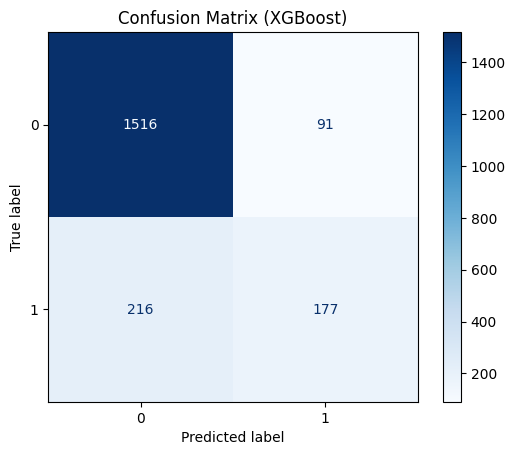

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

# Assuming you want to visualize the best performing model, which is XGBoost based on previous results
# Get the XGBoost model instance
xgb_model = models["XGBoost"]

# Fit the XGBoost model to the training data
xgb_model.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(xgb_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix (XGBoost)")
plt.show()

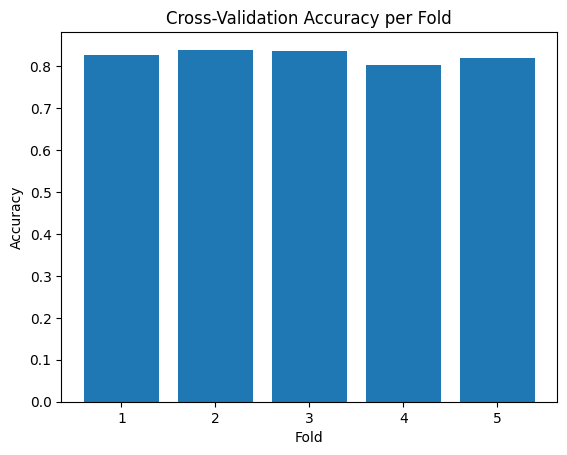

In [ ]:
plt.bar(range(1,6), scores)
plt.title("Cross-Validation Accuracy per Fold")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.show()


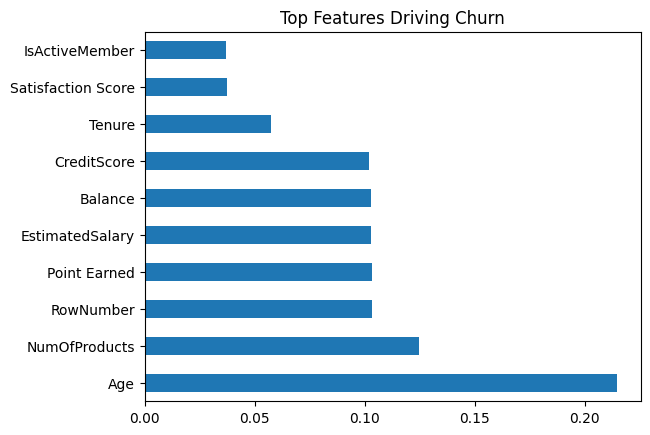

In [ ]:
rf = models["Random Forest"]
rf.fit(X, y)
importances = rf.feature_importances_
features = X.columns
feat_importances = pd.Series(importances, index=features)
feat_importances.nlargest(10).plot(kind='barh')
plt.title("Top Features Driving Churn")
plt.show()

## Key Drivers of Churn

The most important features influencing churn include:
- Age
- Activity status
- Tenure
- Balance

Inactive customers are significantly more likely to leave, while customers with shorter tenure are less loyal. Higher balances may indicate unmet expectations among valuable clients.

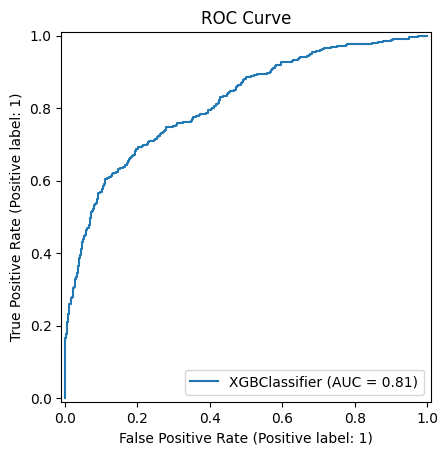

In [ ]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()


The ROC curve evaluates the trade-off between the true positive rate (sensitivity) and the false positive rate (1-specificity) for the logistic regression model at various threshold settings. A higher curve indicates a better performing model, with the model here showing a reasonable performance, as further supported by the calculated AUC score of 0.81.

In [ ]:
from sklearn.metrics import classification_report, roc_auc_score

print(classification_report(y_test, y_pred))
y_prob = model.predict_proba(X_test)[:, 1]
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1607
           1       0.54      0.15      0.23       393

    accuracy                           0.81      2000
   macro avg       0.68      0.56      0.56      2000
weighted avg       0.77      0.81      0.76      2000

ROC-AUC: 0.8148858920340559


## Conclusion and Recommendations

This project successfully developed a model to predict customer churn and identify its key drivers.

### Key Findings:
- Inactive customers are at the highest risk of churning
- Customers with shorter tenure are more likely to leave
- High-balance customers may be dissatisfied

### Recommendations:
- Improve customer engagement through personalized offers
- Focus retention efforts on new customers
- Develop loyalty programs for high-value clients

### Future Work:
- Apply hyperparameter tuning to improve performance
- Address class imbalance using techniques such as SMOTE
- Deploy the model in a real-time prediction system